# Analiza danych e-commerce

**Autor:** Karolina  
**Źródło danych:** Kaggle – zbiór danych e-commerce (CSV)  
**Cel pracy:** Samodzielna eksploracja danych i ich prezentacja; rozwój kreatywności i samodzielności.


In [1]:
import sys

# jeśli biblioteki nie są zainstalowane, odkomentuj następną linię:
# !{sys.executable} -m pip install -U pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ZMIEŃ nazwę pliku na swoją:
file_path = "ecommerce_10000.csv"   # np. "data/ecommerce.csv"

df = pd.read_csv(file_path)

# szybki podgląd
df.head()


,OrderID,Product,Category,Brand,Platform,City,Price,Quantity,TotalAmount,Rating,Reviews,OrderDate
0,ORD100000,Samsung Galaxy A14,Electronics,Samsung,Souq,Cairo,16284.02,1,16284.02,1.39,1684,2024-11-11
1,ORD100001,Nike Air Max,Fashion,Nike,Jumia,Alexandria,6645.20,2,13290.40,2.56,3604,2024-06-22
2,ORD100002,Bluetooth Headset,Accessories,JBL,Jumia,Casablanca,8882.92,3,26648.76,4.98,1257,2024-05-27
3,ORD100003,HP Pavilion Laptop,Computers,HP,Souq,Dubai,3665.44,1,3665.44,1.44,662,2024-07-25
4,ORD100004,iPhone 13,Electronics,Apple,Souq,Casablanca,5210.37,2,10420.74,3.73,2424,2024-02-19


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      10000 non-null  object 
 1   Product      10000 non-null  object 
 2   Category     10000 non-null  object 
 3   Brand        10000 non-null  object 
 4   Platform     10000 non-null  object 
 5   City         10000 non-null  object 
 6   Price        10000 non-null  float64
 7   Quantity     10000 non-null  int64  
 8   TotalAmount  10000 non-null  float64
 9   Rating       10000 non-null  float64
 10  Reviews      10000 non-null  int64  
 11  OrderDate    10000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 937.6+ KB


In [5]:
df.describe()


,Price,Quantity,TotalAmount,Rating,Reviews
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,10027.986331,3.006200,30199.572439,3.005592,2520.072200
std,5728.261196,1.415472,23861.789828,1.154845,1443.849734
min,105.590000,1.000000,113.550000,1.000000,0.000000
25%,4999.862500,2.000000,11066.910000,2.010000,1275.000000
50%,10063.600000,3.000000,23671.630000,3.005000,2537.500000
75%,14938.430000,4.000000,44648.580000,4.000000,3767.000000
max,19999.340000,5.000000,99993.800000,5.000000,5000.000000


In [6]:
# sprawdzenie braków danych
df.isnull().sum()


OrderID        0
Product        0
Category       0
Brand          0
Platform       0
City           0
Price          0
Quantity       0
TotalAmount    0
Rating         0
Reviews        0
OrderDate      0
dtype: int64

In [7]:
# usunięcie duplikatów
df_clean = df.drop_duplicates()

# usunięcie wierszy z brakami
df_clean = df_clean.dropna()

print("Liczba wierszy przed:", len(df))
print("Liczba wierszy po:", len(df_clean))


Liczba wierszy przed: 10000
Liczba wierszy po: 10000


In [10]:
mean_price = df_clean["Price"].mean()
min_price = df_clean["Price"].min()
max_price = df_clean["Price"].max()

print(f"Średnia cena: {mean_price:.2f}")
print(f"Minimalna cena: {min_price:.2f}")
print(f"Maksymalna cena: {max_price:.2f}")



Średnia cena: 10027.99
Minimalna cena: 105.59
Maksymalna cena: 19999.34


In [11]:
avg_order = df_clean["TotalAmount"].mean()
print(f"Średnia wartość zamówienia: {avg_order:.2f}")


Średnia wartość zamówienia: 30199.57


In [12]:
df_clean[["Price", "Quantity", "TotalAmount", "Rating", "Reviews"]].corr()


,Price,Quantity,TotalAmount,Rating,Reviews
Price,1.000000,0.006592,0.726662,-0.007363,-0.003138
Quantity,0.006592,1.000000,0.602311,0.000157,-0.006672
TotalAmount,0.726662,0.602311,1.000000,0.000416,-0.007360
Rating,-0.007363,0.000157,0.000416,1.000000,-0.004611
Reviews,-0.003138,-0.006672,-0.007360,-0.004611,1.000000


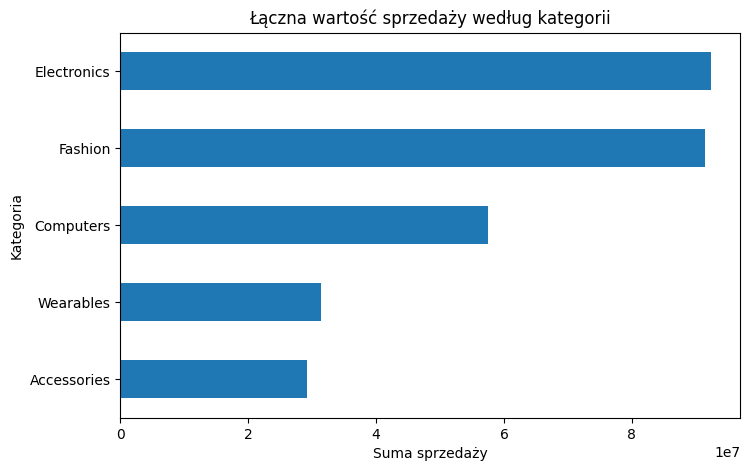

In [13]:
plt.figure(figsize=(8,5))
df_clean.groupby("Category")["TotalAmount"].sum().sort_values().plot(kind="barh")
plt.title("Łączna wartość sprzedaży według kategorii")
plt.xlabel("Suma sprzedaży")
plt.ylabel("Kategoria")
plt.show()


## Interpretacja wyników

Na wykresie przedstawiono łączną wartość sprzedaży według kategorii produktów.
Najwyższe wartości sprzedaży osiągają kategorie elektronika oraz komputery,
co wskazuje na ich dominującą rolę w analizowanym zbiorze e-commerce.
Kategorie o niższej sprzedaży generują mniejszy udział w całkowitych przychodach.
Zróżnicowanie wyników pomiędzy kategoriami pokazuje, że struktura oferty
ma istotny wpływ na wyniki finansowe sklepu internetowego.
